In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
from warnings import filterwarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
filterwarnings("ignore")

# Load the Dataset

In [19]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Understand And Organize the Dataset

In [20]:
# Check data types
print(f"x_train data type: {type(x_train)}")
print(f"y_train data type: {type(y_train)}")
print(f"x_test data type: {type(x_test)}")
print(f"y_test data type: {type(y_test)}\n")

# Check shapes of the datasets
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Check unique values in target variables
print(f"Unique values in y_train: {np.unique(y_train)}")
print(f"Unique values in y_test: {np.unique(y_test)}\n")

# Check if there is any missing data
print(f"Any missing values in x_train: {np.any(np.isnan(x_train))}")
print(f"Any missing values in y_train: {np.any(np.isnan(y_train))}")
print(f"Any missing values in x_test: {np.any(np.isnan(x_test))}")
print(f"Any missing values in y_test: {np.any(np.isnan(y_test))}")

x_train data type: <class 'numpy.ndarray'>
y_train data type: <class 'numpy.ndarray'>
x_test data type: <class 'numpy.ndarray'>
y_test data type: <class 'numpy.ndarray'>

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)

Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique values in y_test: [0 1 2 3 4 5 6 7 8 9]

Any missing values in x_train: False
Any missing values in y_train: False
Any missing values in x_test: False
Any missing values in y_test: False


In [21]:
num_labels = len(np.unique(y_train))
num_labels

10

## Frequency Distribution of Target Labels y_train and y_test

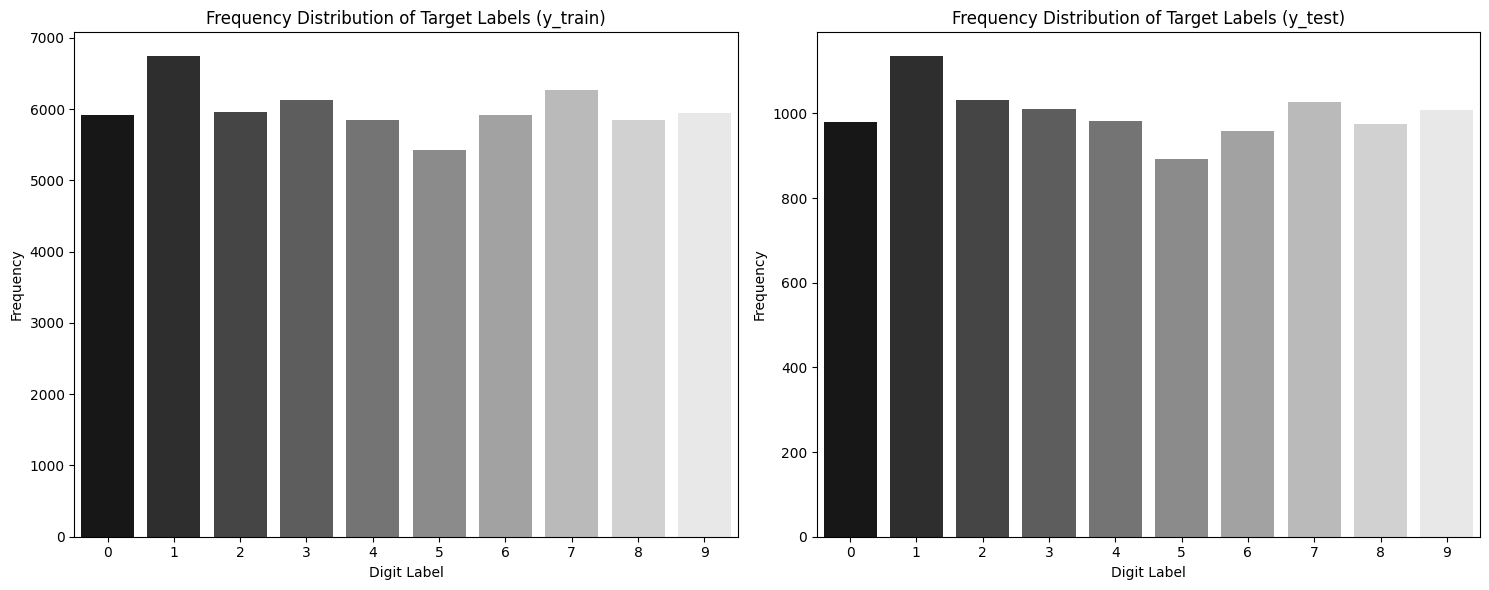

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x=y_train, palette='gray', ax=axes[0])
axes[0].set_title('Frequency Distribution of Target Labels (y_train)')
axes[0].set_xlabel('Digit Label')
axes[0].set_ylabel('Frequency')

sns.countplot(x=y_test, palette='gray', ax=axes[1])
axes[1].set_title('Frequency Distribution of Target Labels (y_test)')
axes[1].set_xlabel('Digit Label')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Visualization of Some Digits and Their Labels

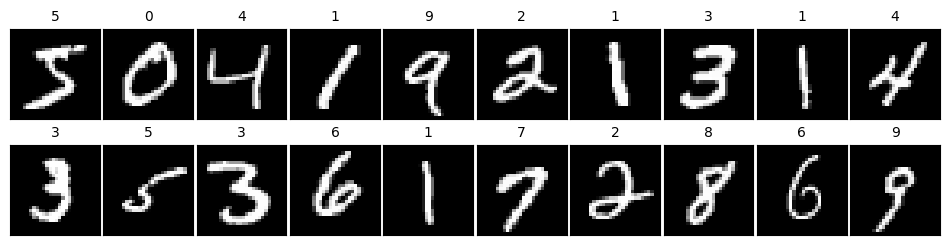

In [7]:
def visualize_images(data):
    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01},
                             squeeze=True)

    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train[i]), fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_images(x_train)

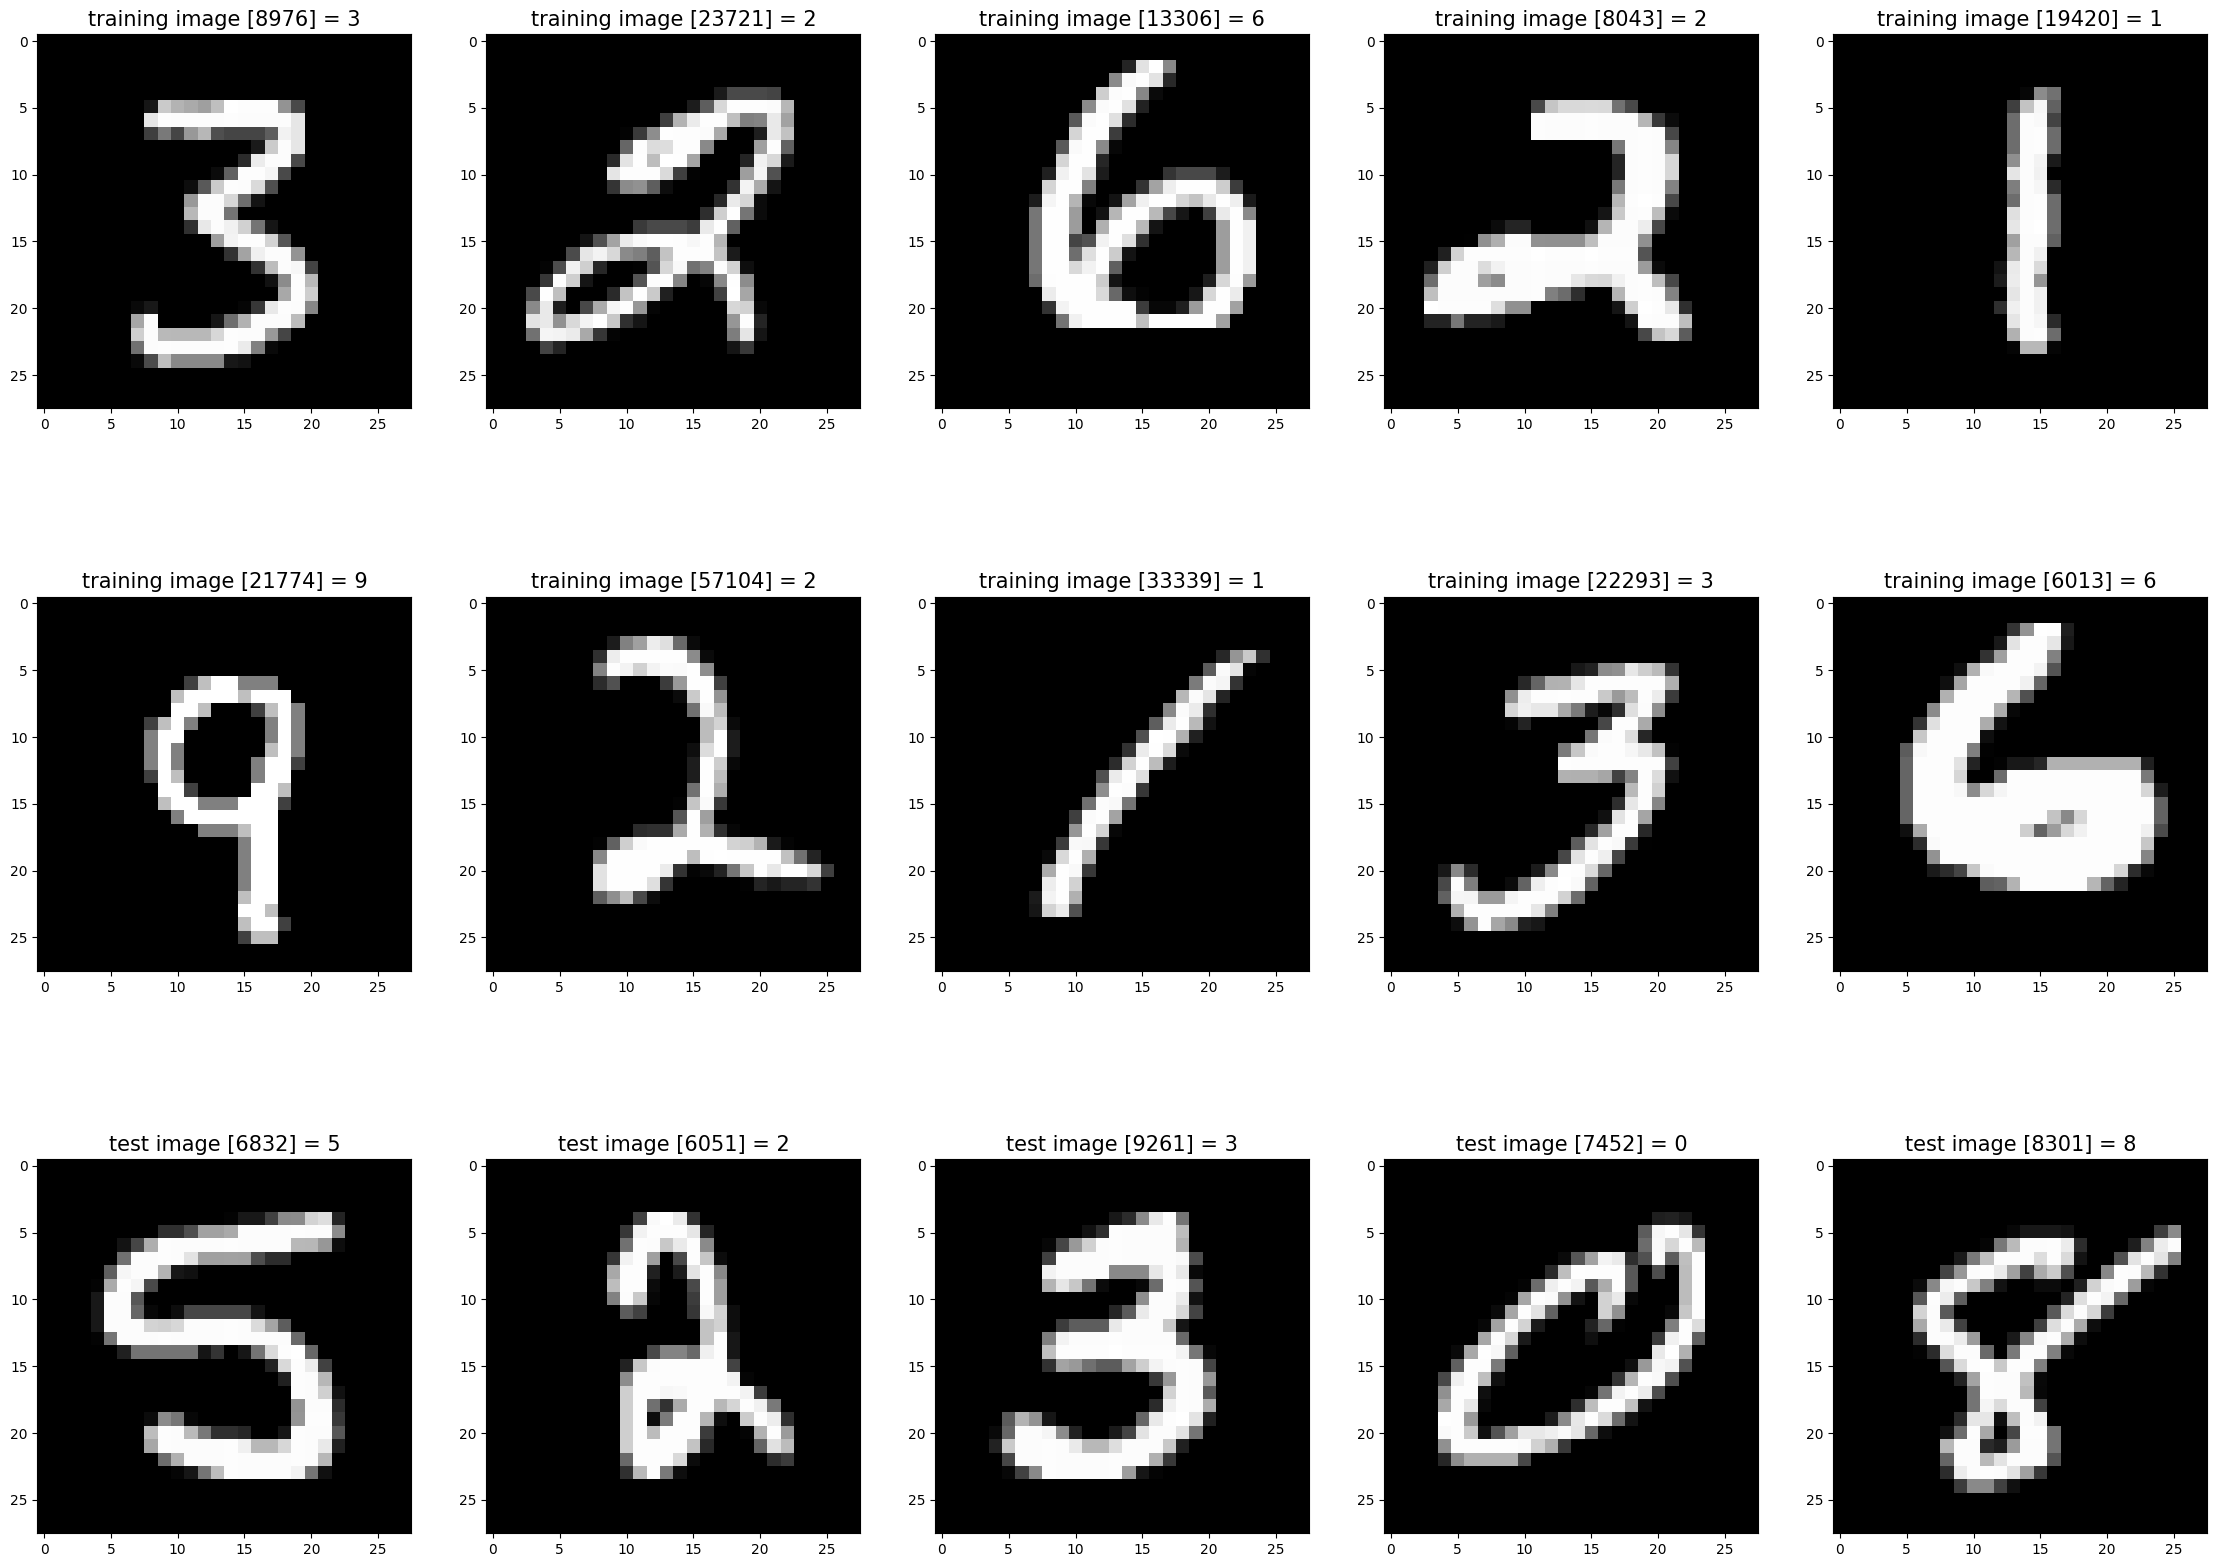

In [8]:
# Show example images
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(28, 28))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1

random_images = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    random_images.append((x_train[r], 'training image [' + str(r) + '] = ' + str(y_train[r])))
for i in range(0, 5):
    r = random.randint(1, 10000)
    random_images.append((x_test[r], 'test image [' + str(r) + '] = ' + str(y_test[r])))

show_images(list(map(lambda x: x[0], random_images)), list(map(lambda x: x[1], random_images)))

In [9]:
## Visualizing an Image with Pixel Values

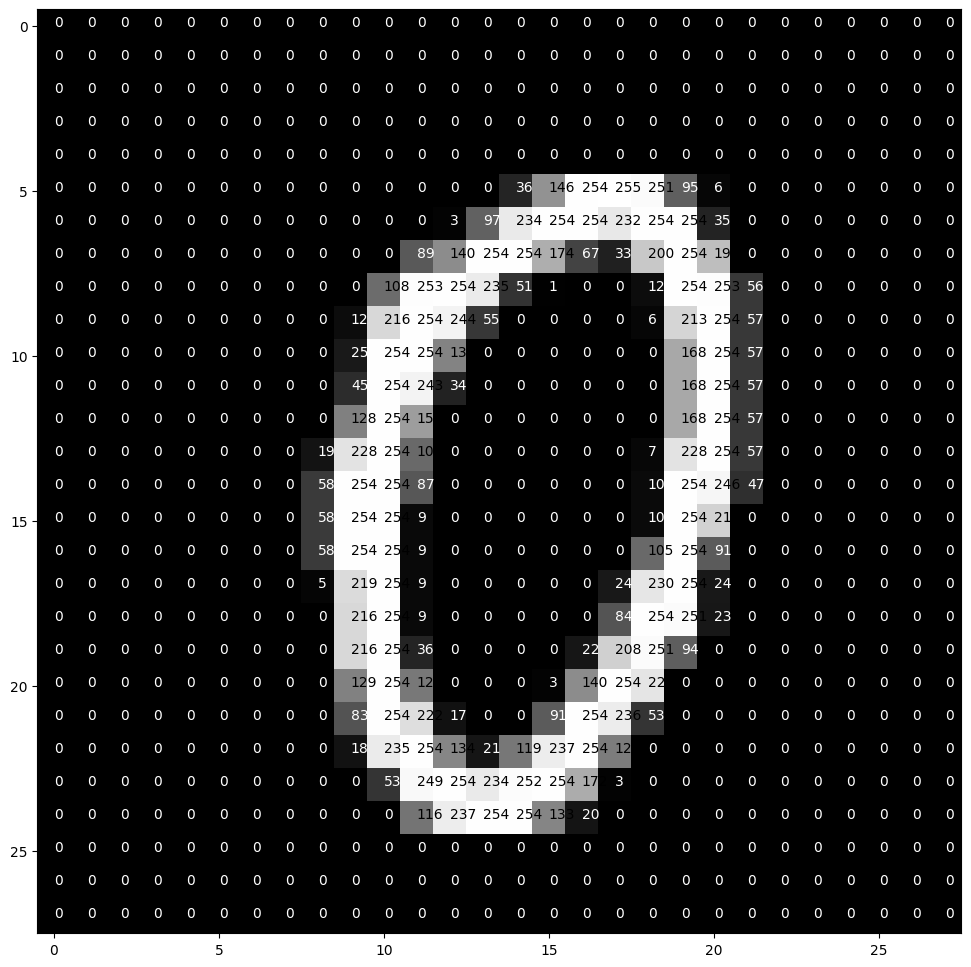

In [10]:
def pixel_visualize(img):
    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")
    width, height = img.shape
    threshold = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y], 2)), xy=(y,x),
                       color='white' if img [x][y]<threshold else 'black')

pixel_visualize(x_train[1000])

# Preprocessing

## Normalization

In [22]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [23]:
# Flatten the images from (batch, 28, 28) to (batch, 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

## One Hot Encoding

In [24]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [25]:
y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

# Building Functions

In [26]:
def softmax_crossentropy_with_logits(logits, reference_answers):
    logits_for_answers = logits[np.arange(len(logits)), reference_answers]
    xentropy = - logits_for_answers + np.log(np.sum(np.exp(logits), axis=-1))
    return xentropy

def grad_softmax_crossentropy_with_logits(logits, reference_answers):
    ones_for_answers = np.zeros_like(logits)
    ones_for_answers[np.arange(len(logits)), reference_answers] = 1
    softmax = np.exp(logits) / np.exp(logits).sum(axis=-1,keepdims=True)
    return (- ones_for_answers + softmax) / logits.shape[0]

class Layer(object):
    def __init__(self):
        pass

    def forward(self, input):
        return input

    def backward(self, input, grad_output):
        num_units = input.shape[1]
        d_layer_d_input = np.eye(num_units)
        return np.dot(grad_output, d_layer_d_input) # chain rule


class ReLU(Layer):
    def __init__(self):
        pass

    def forward(self, input):
        relu_forward = np.maximum(0, input)
        return relu_forward

    def backward(self, input, grad_output):
        relu_grad = input > 0
        return grad_output * relu_grad

class Dense(Layer):
    def __init__(self, input_units, output_units, learning_rate = 0.1):
        self.learning_rate = learning_rate
        self.weights = np.random.normal(loc=0.0, scale = np.sqrt(2 / (input_units + output_units)), size = (input_units, output_units))
        self.biases = np.zeros(output_units)

    def forward(self, input):
        return np.dot(input, self.weights) + self.biases

    def backward(self, input, grad_output):
        grad_input = np.dot(grad_output, self.weights.T)

        grad_weights = np.dot(input.T, grad_output)
        grad_biases = grad_output.mean(axis=0) * input.shape[0]
        assert grad_weights.shape == self.weights.shape and grad_biases.shape == self.biases.shape

        self.weights = self.weights - self.learning_rate * grad_weights
        self.biases = self.biases - self.learning_rate * grad_biases

        return grad_input


class SLP(object):
    def __init__(self):
        self.layers = []

    def add_layer(self, layer):
        self.layers.append(layer)

    def forward(self, X):
        activations = []
        input = X

        for l in self.layers:
            activations.append(l.forward(input))
            input = activations[-1]

        assert len(activations) == len(self.layers)
        return activations


    def train_batch(self, X, y):
        layer_activations = self.forward(X)
        layer_inputs = [X] + layer_activations  # layer_input[i] is an input for layer[i]
        logits = layer_activations[-1]

        y_argmax =  y.argmax(axis=1)
        loss = softmax_crossentropy_with_logits(logits, y_argmax)
        loss_grad = grad_softmax_crossentropy_with_logits(logits, y_argmax)

        for layer_index in range(len(self.layers))[::-1]:
            layer = self.layers[layer_index]
            loss_grad = layer.backward(layer_inputs[layer_index], loss_grad) # grad w.r.t. input, also weight updates

        return np.mean(loss)

    def train(self, X_train, y_train, n_epochs = 25, batch_size = 32):
        train_log = []

        for epoch in range(n_epochs):
            for i in range(0, X_train.shape[0], batch_size):
                x_batch = X_train[i:i + batch_size]
                y_batch = y_train[i:i + batch_size]
                self.train_batch(x_batch, y_batch)

            train_accuracy = np.mean(self.predict(X_train) == y_train.argmax(axis=-1))
            train_log.append(train_accuracy)
            print(f"Epoch: {epoch + 1}, Train accuracy: {train_log[-1]}")

        return train_log

    def predict(self, X):
        logits = self.forward(X)[-1]
        return logits.argmax(axis=-1)

# Build Model

In [27]:
print('X_train.shape', x_train.shape)
print('Y_train.shape', y_train.shape)
input_size = x_train.shape[1]
output_size = y_train.shape[1]

X_train.shape (60000, 784)
Y_train.shape (60000, 10)


In [28]:
model = SLP()
model.add_layer(Dense(input_size, output_size, learning_rate = 0.05))

# Training

Epoch: 1, Train accuracy: 0.8887
Epoch: 2, Train accuracy: 0.9008666666666667
Epoch: 3, Train accuracy: 0.9065333333333333
Epoch: 4, Train accuracy: 0.9103166666666667
Epoch: 5, Train accuracy: 0.9128
Epoch: 6, Train accuracy: 0.9144833333333333
Epoch: 7, Train accuracy: 0.9157666666666666
Epoch: 8, Train accuracy: 0.9171166666666667
Epoch: 9, Train accuracy: 0.9178666666666667
Epoch: 10, Train accuracy: 0.9188333333333333
Epoch: 11, Train accuracy: 0.9194
Epoch: 12, Train accuracy: 0.9200166666666667
Epoch: 13, Train accuracy: 0.9207166666666666
Epoch: 14, Train accuracy: 0.92125
Epoch: 15, Train accuracy: 0.9217
Epoch: 16, Train accuracy: 0.9222
Epoch: 17, Train accuracy: 0.9226833333333333
Epoch: 18, Train accuracy: 0.9230333333333334
Epoch: 19, Train accuracy: 0.92335
Epoch: 20, Train accuracy: 0.9237166666666666
Epoch: 21, Train accuracy: 0.9241
Epoch: 22, Train accuracy: 0.9242833333333333
Epoch: 23, Train accuracy: 0.9247166666666666
Epoch: 24, Train accuracy: 0.9251
Epoch: 25, 

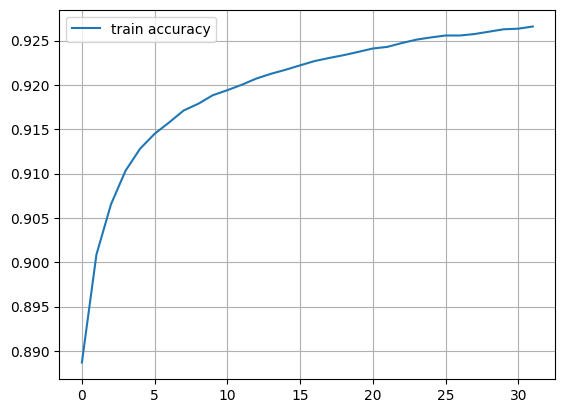

In [29]:
train_log = model.train(x_train, y_train, n_epochs = 32, batch_size = 64)
plt.plot(train_log,label = 'train accuracy')
plt.legend(loc='best')
plt.grid()
plt.show()

# Export Weights

In [34]:
FRAC_BITS = 4
INPUT_WEIGHT_SCALE = 2 ** FRAC_BITS       # 16
BIAS_SCALE = 2 ** (FRAC_BITS * 2)         # 256

def export_array_to_hex(data_array, filename, bit_width):
    min_val = -(2**(bit_width-1))
    max_val = (2**(bit_width-1) - 1)
    quantized = np.clip(np.round(data_array), min_val, max_val).astype(np.int64)

    mask = (1 << bit_width) - 1
    hex_chars = bit_width // 4

    with open(filename, 'w') as f:
        for val in quantized:
            f.write(f"{val & mask:0{hex_chars}x}\n")
    print(f"Exported {len(quantized)} values to {filename}")

def generate_hardware_files(x_test, y_test, weights, biases, num_samples=3):
    q_weights = np.round(weights * INPUT_WEIGHT_SCALE)
    q_biases = np.round(biases * BIAS_SCALE)

    export_array_to_hex(q_weights.flatten(), "weights_784x10.hex", bit_width=8)
    export_array_to_hex(q_biases.flatten(), "biases_10.hex", bit_width=32)

    expected_classes = []

    for i in range(num_samples):
        actual_label = np.argmax(y_test[i])

        img = x_test[i].flatten()
        q_img = np.round(img * INPUT_WEIGHT_SCALE)

        export_array_to_hex(q_img, f"test_image_{i}.hex", bit_width=8)
        mac_accumulators = np.dot(q_img.astype(np.int64), q_weights.astype(np.int64))
        final_outputs = mac_accumulators + q_biases.astype(np.int64)
        predicted_class = np.argmax(final_outputs)
        expected_classes.append(predicted_class)

        print(f"\nSample {i}: Actual Label = {actual_label} | Hardware Will Predict = {predicted_class}")
        export_array_to_hex(final_outputs, f"expected_accumulators_{i}.hex", bit_width=32)

    print(f"\nExpected Class Sequence: {expected_classes}")

generate_hardware_files(
    x_test=x_test,
    y_test=y_test,
    weights=model.layers[0].weights,
    biases=model.layers[0].biases,
    num_samples=3
)

Exported 7840 values to weights_784x10.hex
Exported 10 values to biases_10.hex
Exported 784 values to test_image_0.hex

Sample 0: Actual Label = 7 | Hardware Will Predict = 7
Exported 10 values to expected_accumulators_0.hex
Exported 784 values to test_image_1.hex

Sample 1: Actual Label = 2 | Hardware Will Predict = 2
Exported 10 values to expected_accumulators_1.hex
Exported 784 values to test_image_2.hex

Sample 2: Actual Label = 1 | Hardware Will Predict = 1
Exported 10 values to expected_accumulators_2.hex

Expected Class Sequence: [np.int64(7), np.int64(2), np.int64(1)]
